# <B>Lec.2 딥러닝_군집 모델  - iris

* <b>답지(target)이 없는 비지도학습(unsupervised)
* <b>데이터를 비슷한 것끼리 그룹을 묶는 것
* <b>데이터의 전반적 특징 파악에 유용

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Ft98JC%2Fbtsa6CuL7nS%2FAAAAAAAAAAAAAAAAAAAAAK32wdgXML8riDq-x9JGCuY2AwTjYVYT8-E5c199JyIX%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3DKy8pieVl3HumS%252B8GnrZzQNZPjzw%253D" width=500> 

<img src="https://scikit-learn.org/0.15/_images/plot_cluster_comparison_0011.png">

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split                   

#-----------------------------------------------------------------------------------  ML 모델
from sklearn.ensemble import RandomForestClassifier 
#----------------------------------------------------------------------------------   DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------  평가
from sklearn.metrics  import accuracy_score,      f1_score



# =========================================================================================

import warnings
warnings.filterwarnings('ignore')


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# <B>Data Load

In [6]:
from sklearn.datasets import load_iris
X, y = load_iris(as_frame=True , return_X_y=True)
X.columns = ["sl","sw","pl","pw"]
X.head(2)

,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


# <b> 머신러닝(분류) 모델 점수

In [8]:
X80,X20, y80, y20 = train_test_split(X, y, test_size=0.2,random_state=4878, shuffle=True, stratify=y)
model = RandomForestClassifier(random_state=5787)
model.fit(X80, y80)
pred = model.predict(X20)

acc = accuracy_score(y20, pred)
f1  = f1_score(y20, pred, average="macro")
print(f"acc: {acc:.4f}  f1 : {f1:.4f}") 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


acc: 0.9667  f1 : 0.9666


# <b> 딥러닝 모델 점수

In [36]:
model = Sequential([
    Dense(10, activation="relu", input_dim=4 ), # ---- input layer
    Dense(16, activation="relu"              ), # ---- hidden Layer 3
    Dense(24, activation="relu"              ),
    Dense(8,  activation="relu"              ),
    Dense(3,  activation="softmax"           )  # ---- output layer
])

In [29]:
# --------------- 컴파일 안에 L,O,M 3개 넣어야함 (L_loss, O_optimizer, M_metrics)
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]) 

In [30]:
model.summary()


# param # : AI 모델이 학습을 통해 기억해야 할 '가중치(Weight)와 편향(Bias)의 총 개수 (공식의 개수)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 861 (3.36 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
res = model.fit(   X80, y80,   epochs=50,   validation_data =(X20,y20)   )
res

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5833 - loss: 1.0644 - val_accuracy: 0.6667 - val_loss: 1.0442
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 1.0371 - val_accuracy: 0.6667 - val_loss: 1.0163
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 1.0110 - val_accuracy: 0.6667 - val_loss: 0.9915
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6667 - loss: 0.9873 - val_accuracy: 0.6667 - val_loss: 0.9654
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.9617 - val_accuracy: 0.6333 - val_loss: 0.9424
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 0.9346 - val_accuracy: 0.9000 - val_loss: 0.9166
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9167 - loss: 0.9069 - val_accuracy: 0.8333 - val_loss: 0.8888
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7000 - loss: 0.8813 - val_accuracy: 0.6667 - val_loss: 0.8613


In [32]:
loss,acc = model.evaluate(X20,y20)
print(f"acc : {acc:.4f}, loss : {loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9333 - loss: 0.1364
acc : 0.9333, loss : 0.1364


In [33]:
res.history
# dictionary 형태 확인 가능

{'accuracy': [0.5833333134651184,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.8333333134651184,
  0.9166666865348816,
  0.699999988079071,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.675000011920929,
  0.675000011920929,
  0.6916666626930237,
  0.7416666746139526,
  0.7583333253860474,
  0.7833333611488342,
  0.8333333134651184,
  0.8916666507720947,
  0.925000011920929,
  0.9416666626930237,
  0.9333333373069763,
  0.949999988079071,
  0.9750000238418579,
  0.9666666388511658,
  0.9583333134651184,
  0.9750000238418579,
  0.9833333492279053,
  0.9833333492279053,
  0.9750000238418579,
  0.9750000238418579,
  0.9833333492279053,
  0.9833333492279053,
  0.9833333492279053,
  0.9833333492279053,
  0.9833333492279053,
  0.9916666746139526,
  0.9833333492279053,
  0.9833333492279053,
  0.9833333492279053,
  0.9833333492279053,
  0.9833333492279053,
  0.9916666746139526,
  0.9833333492279053,
  0

In [34]:
res.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

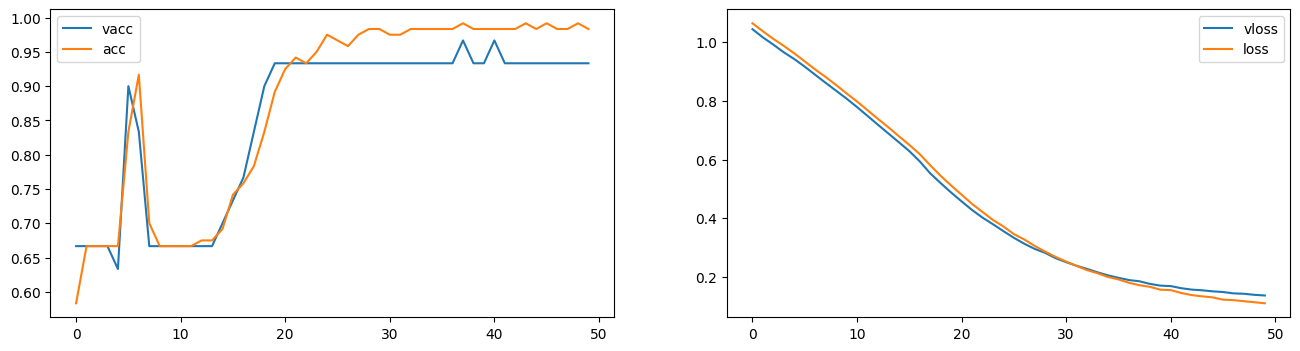

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(50), vacc , label="vacc")
plt.plot(range(50), acc  , label="acc")
plt.legend()
plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="vloss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show();

<b> 결론 _ data 갯수가 너무 적어서 ML 성능이 더 우수하게 나옴 

## <b> Categorical_crossentropy

### <b> 1. PANDAS - get_dummies

In [44]:
y[:10]

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64

In [46]:
y_encoded1 = pd.get_dummies(y, dtype=int)
y_encoded1.head(5)

,0,1,2
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


### <b> 2. SKLEARN - OneHotEncoder

```python
class sklearn.preprocessing.OneHotEncoder(*, categories='auto', drop=None, sparse_output=True, dtype=<class 'numpy.float64'>, handle_unknown='error', min_frequency=None, max_categories=None, feature_name_combiner='concat')[source]

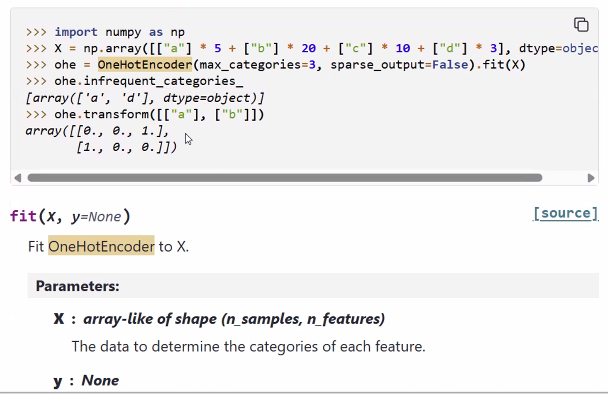

In [42]:
from sklearn.preprocessing   import OneHotEncoder

In [48]:
# 1. 객체 생성 (sparse_output=False로 해야 넘파이 배열로 바로 보임)
encoder = OneHotEncoder(sparse_output=False)

# 2. 데이터를 2차원으로 변형 후 학습 및 변환
# y.values.reshape(-1, 1)은 세로 한 줄 형태로 만드는 과정입니다.
y_reshaped = np.array(y).reshape(-1, 1)
y_encoded2 = encoder.fit_transform(y_reshaped)

print(y_encoded2[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


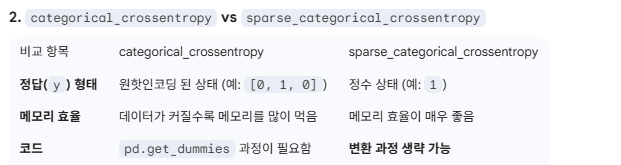

### <b> 3. TENSORFLOW - to_categorical

```python
tf.keras.utils.to_categorical(y, num_classes=None, dtype='float32')

In [49]:
from tensorflow.keras.utils import to_categorical

In [51]:
y_encoded3 = to_categorical(y)
y_encoded3[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [59]:
# y_encoded 형태로 넣어서 학습 시, y -> y_encoded로 넣어줘야함!
X80, X20, yoh80, yoh20 = train_test_split(X, y_encoded3, test_size=0.2, random_state=4878, shuffle=True, stratify=y)

model = Sequential([
    Dense(10, activation="relu", input_dim=4 ), # ---- input layer
    Dense(16, activation="relu"              ), # ---- hidden Layer 3
    Dense(24, activation="relu"              ),
    Dense(8,  activation="relu"              ),
    Dense(3,  activation="softmax"           )  # ---- output layer
])

# --------------- 컴파일 안에 L,O,M 3개 넣어야함 (L_loss, O_optimizer, M_metrics)
# --------------- encoded_y 니까 sparse 지우고 "categorical_crossentropy"
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]) 




## loss="(sparce_)categorical_crossentropy" 는 오직 **군집(분류)**에서만
## **회귀**는 무조건    loss="mse"

In [56]:
res = model.fit(X80, yoh80, epochs=50, validation_data=(X20, yoh20))
res

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3333 - loss: 1.7678 - val_accuracy: 0.3333 - val_loss: 1.6447
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.5984 - val_accuracy: 0.3333 - val_loss: 1.4916
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.4586 - val_accuracy: 0.3333 - val_loss: 1.3655
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.3448 - val_accuracy: 0.3333 - val_loss: 1.2665
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.2481 - val_accuracy: 0.3333 - val_loss: 1.1945
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3333 - loss: 1.1875 - val_accuracy: 0.3333 - val_loss: 1.1433
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3333 - loss: 1.1357 - val_accuracy: 0.3333 - val_loss: 1.1077
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.1047 - val_accuracy: 0.3333 - val_loss: 1.0818


In [57]:
loss, acc = model.evaluate(X20, yoh20)
print(f"acc : {acc:.4f}, loss:{loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9333 - loss: 0.5910
acc : 0.9333, loss:0.5910


# <b> 모델 및 가중치 저장

In [60]:
# 이거 너무 옛날 모델이라 최신형 아래 셀 참고 

# # <b> 모델 저장 - HDF5(Hierarchical Data Format version 5) 
# > <big><b>.h5 확장자 - 모델, 가중치 모두 저장 가능 / Keras(TENSORFLOW)로 오픈 가능
# > ![{2DBFE858-17C8-4DCF-8C1F-8EF05EA5B0B0}.png](attachment:fa4dbab9-c5e2-4ee7-8512-ffae355faedb.png) 

In [61]:
from tensorflow.keras.models import load_model, save_model

# 모델 저장    _ [ 모델 설계도 / 학습된 가중치 / 컴파일 설정 ]이 함께 저장됨
save_model(model, "lec.02_cls_iris.keras")
print(" === 모델 저장 완료 === ")

 === 모델 저장 완료 === 


In [62]:
# 모델 불러오기
re_model = load_model("lec.02_cls_iris.keras")
re_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                     │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,585 (10.10 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,724 (6.74 KB)

# <b> 가중치만 저장
> 범용적으로 사용하는 모델을 활용할 경우 <br>
> 확장자명 : .weights.h5

In [64]:
from tensorflow.keras.saving import load_weights, save_weights

# 1. 가중치만 따로 저장 (.weights.h5 확장자 사용)
# 모델의 설계도는 저장되지 않고, 학습된 숫자(Weight, Bias)만 저장됩니다.
save_weights(re_model, "lec.02_cls_iris.weights.h5")
print(" === 가중치 저장 완료 === ")

 === 가중치 저장 완료 === 


In [65]:
# 2. 가중치 불러오기 (중요: 변수에 대입하지 말고 모델 객체에 직접 적용)
# load_weights는 re_model의 내부 값을 직접 업데이트하며, None을 반환합니다.
load_weights(re_model, "lec.02_cls_iris.weights.h5")

In [67]:
# 3. 업데이트된 모델에서 가중치 확인하기
weights = re_model.get_weights()
print(weights)

[array([[ 0.44287014,  0.27250427,  0.12203926,  0.38748753, -0.45436025,
        -0.5251306 ,  0.31738472, -0.28850278,  0.4366852 , -0.15991512],
       [-0.00282198, -0.55540997, -0.12390989,  0.37261486, -0.12667269,
         0.28213233, -0.3762389 ,  0.23696196,  0.3341    , -0.51945454],
       [ 0.64510226,  0.09400576, -0.6357355 , -0.5635284 ,  0.5231601 ,
         0.5657537 ,  0.25781935,  0.17790788, -0.0180223 ,  0.23221791],
       [ 0.28763622,  0.08749479,  0.44943357, -0.01764864, -0.00531584,
        -0.5572155 ,  0.2488994 , -0.47167718, -0.43268004, -0.11395955]],
      dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[ 0.3988706 , -0.2075068 ,  0.37993014,  0.2998613 ,  0.3267293 ,
        -0.07549977,  0.02904373, -0.05740464, -0.0369772 , -0.20964009,
        -0.16843653, -0.43734437,  0.30677253,  0.14295018,  0.20411736,
        -0.20018783],
       [-0.02224338,  0.31103456, -0.15227118, -0.01184875, -0.47833285,
        -0